In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('fraud_data.csv')
df.head()

,timestamp,amount,merchant_category,account_balance,is_new_merchant,distance_from_home,is_international,is_card_present,txns_last_24h,round_amount_flag,amount_to_balance_ratio,hour_of_day,day_of_week,is_fraud
0,2025-03-26 16:38:00,48.60,healthcare,7464.70,1,7.9,0,1,4,0,0.007,16,2,0
1,2025-04-02 14:52:00,30.35,dining,866.90,0,0.7,0,0,0,0,0.035,14,2,0
2,2025-09-12 01:18:00,6.78,entertainment,433.40,0,3.2,0,1,2,0,0.016,1,4,0
3,2025-06-29 23:38:00,550.29,dining,153.54,0,57.7,0,1,2,0,3.584,23,6,0
4,2025-03-18 13:48:00,15.55,grocery,462.34,0,50.9,0,0,1,0,0.034,13,1,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   timestamp                100000 non-null  str    
 1   amount                   100000 non-null  float64
 2   merchant_category        100000 non-null  str    
 3   account_balance          100000 non-null  float64
 4   is_new_merchant          100000 non-null  int64  
 5   distance_from_home       100000 non-null  float64
 6   is_international         100000 non-null  int64  
 7   is_card_present          100000 non-null  int64  
 8   txns_last_24h            100000 non-null  int64  
 9   round_amount_flag        100000 non-null  int64  
 10  amount_to_balance_ratio  100000 non-null  float64
 11  hour_of_day              100000 non-null  int64  
 12  day_of_week              100000 non-null  int64  
 13  is_fraud                 100000 non-null  int64  
dtypes: float64(4), i

In [5]:
df.describe()

,amount,account_balance,is_new_merchant,distance_from_home,is_international,is_card_present,txns_last_24h,round_amount_flag,amount_to_balance_ratio,hour_of_day,day_of_week,is_fraud
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000
mean,112.580996,3284.199592,0.150440,20.024539,0.080400,0.84859,1.996930,0.000070,0.267152,11.51182,3.010600,0.026880
std,203.502760,7524.784250,0.357504,20.082446,0.271913,0.35845,1.415444,0.008366,1.066356,6.93563,2.001841,0.161734
min,1.000000,50.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,24.470000,398.120000,0.000000,5.700000,0.000000,1.00000,1.000000,0.000000,0.014000,5.00000,1.000000,0.000000
50%,54.730000,1096.220000,0.000000,13.900000,0.000000,1.00000,2.000000,0.000000,0.050000,12.00000,3.000000,0.000000
75%,123.020000,3015.987500,0.000000,27.700000,0.000000,1.00000,3.000000,0.000000,0.183000,18.00000,5.000000,0.000000
max,17358.150000,100000.000000,1.000000,239.600000,1.000000,1.00000,11.000000,1.000000,110.262000,23.00000,6.000000,1.000000


In [7]:
df['is_fraud'].value_counts(normalize=True)

is_fraud
0    0.97312
1    0.02688
Name: proportion, dtype: float64

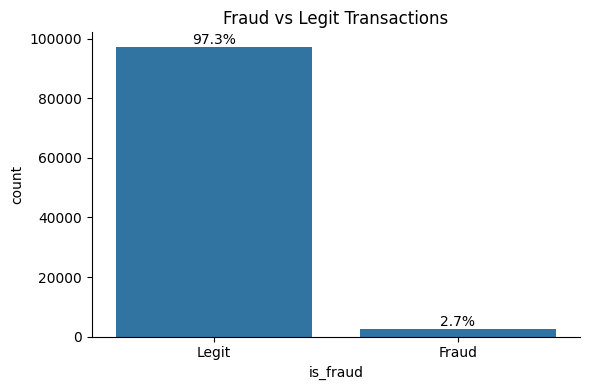

In [17]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='is_fraud', data=df)
plt.xticks([0, 1], ['Legit', 'Fraud'])
plt.title('Fraud vs Legit Transactions')
total = len(df)
for bar in ax.containers[0]:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height / total:.1%}', ha='center', va='bottom')
sns.despine()
plt.tight_layout()
plt.show()

In [21]:
for col in ['is_new_merchant', 'is_international', 'is_card_present', 'round_amount_flag']:
    print(f'{col}:\n{df.groupby(col)["is_fraud"].mean()}\n')

is_new_merchant:
is_new_merchant
0    0.016514
1    0.085416
Name: is_fraud, dtype: float64

is_international:
is_international
0    0.018682
1    0.120647
Name: is_fraud, dtype: float64

is_card_present:
is_card_present
0    0.085133
1    0.016486
Name: is_fraud, dtype: float64

round_amount_flag:
round_amount_flag
0    0.026862
1    0.285714
Name: is_fraud, dtype: float64



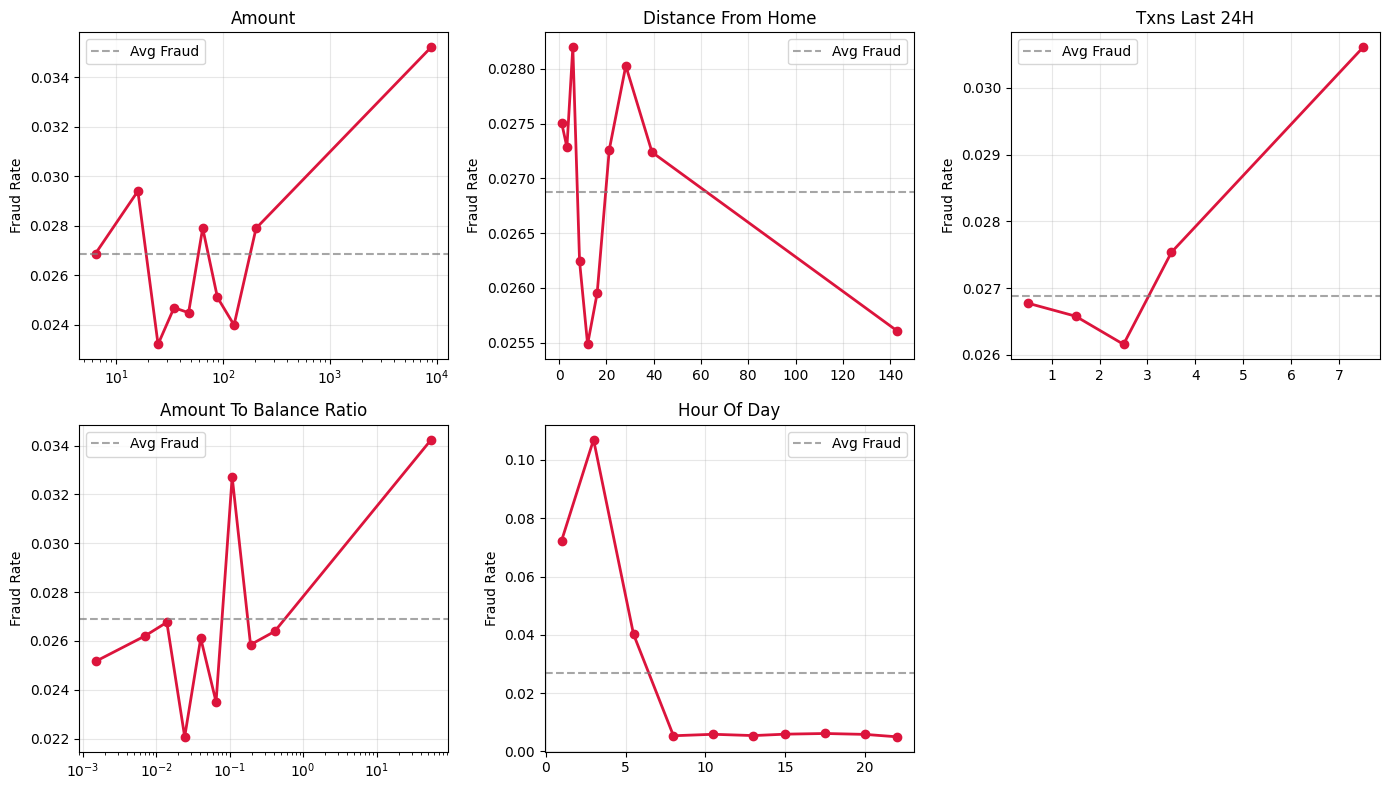

In [29]:
cont_features = ['amount', 'distance_from_home', 'txns_last_24h',
                 'amount_to_balance_ratio', 'hour_of_day']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(cont_features):
    df['bin'] = pd.qcut(df[col], q=10, duplicates='drop')
    fraud_rate = df.groupby('bin', observed=False)['is_fraud'].mean()
    bins = fraud_rate.index.categories
    if isinstance(bins[0], pd.Interval):
        x = [(b.left + b.right) / 2 for b in bins]
    else:
        x = range(len(bins))
    axes[i].plot(x, fraud_rate.values, marker='o', color='crimson', linewidth=2)
    axes[i].axhline(df['is_fraud'].mean(), color='gray', linestyle='--', alpha=0.7, label='Avg Fraud')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=12)
    axes[i].set_ylabel('Fraud Rate')
    axes[i].legend()
    axes[i].grid(alpha=0.3)
    if col in ['amount', 'amount_to_balance_ratio']:
        axes[i].set_xscale('log')
df.drop(columns='bin', inplace=True)
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

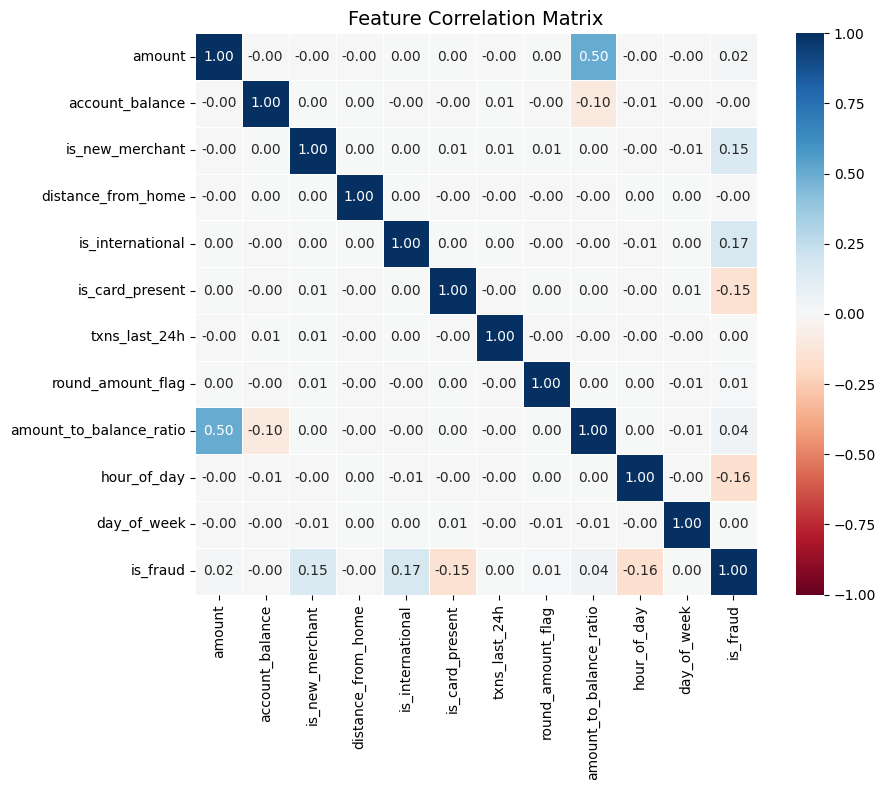

In [34]:
corr = df.select_dtypes('number').corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu', center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

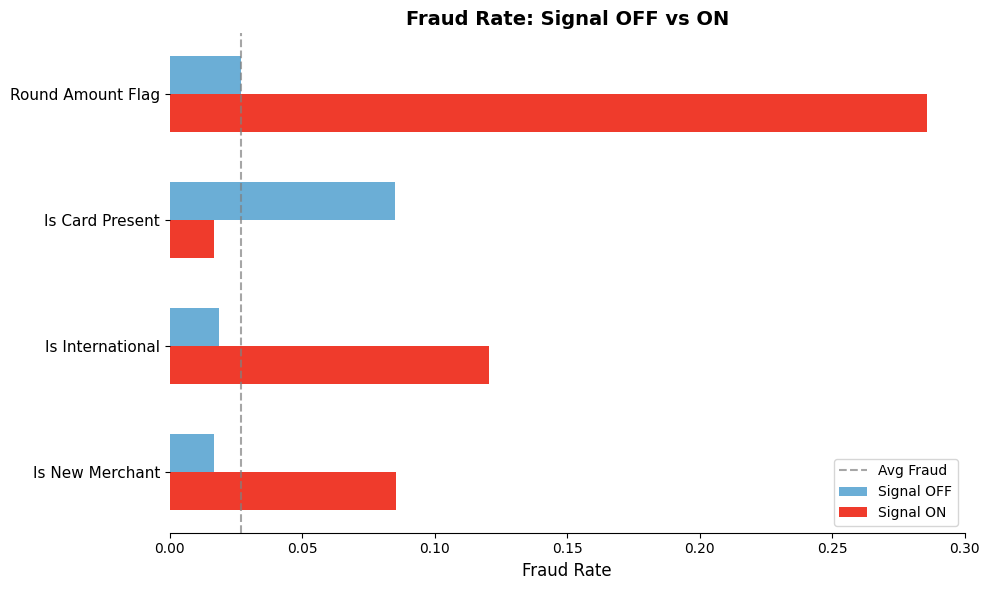

In [36]:
binary_cols = ['is_new_merchant', 'is_international', 'is_card_present', 'round_amount_flag']
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(binary_cols))
off_rates = [df.groupby(c)['is_fraud'].mean().iloc[0] for c in binary_cols]
on_rates  = [df.groupby(c)['is_fraud'].mean().iloc[1] for c in binary_cols]
bar_height = 0.3
ax.barh([y + bar_height/2 for y in y_pos], off_rates, bar_height,
        label='Signal OFF', color='#6baed6')
ax.barh([y - bar_height/2 for y in y_pos], on_rates, bar_height,
        label='Signal ON', color='#ef3b2c')
labels = [c.replace('_', ' ').title() for c in binary_cols]
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11)
ax.axvline(df['is_fraud'].mean(), color='gray', linestyle='--', alpha=0.7, label='Avg Fraud')
ax.set_xlabel('Fraud Rate', fontsize=12)
ax.set_title('Fraud Rate: Signal OFF vs ON', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
sns.despine(left=True)
plt.tight_layout()
plt.show()

C:\Users\youssef besheer\AppData\Local\Temp\ipykernel_67324\499686702.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='merchant_category', y='is_fraud', data=df, order=cat_order,


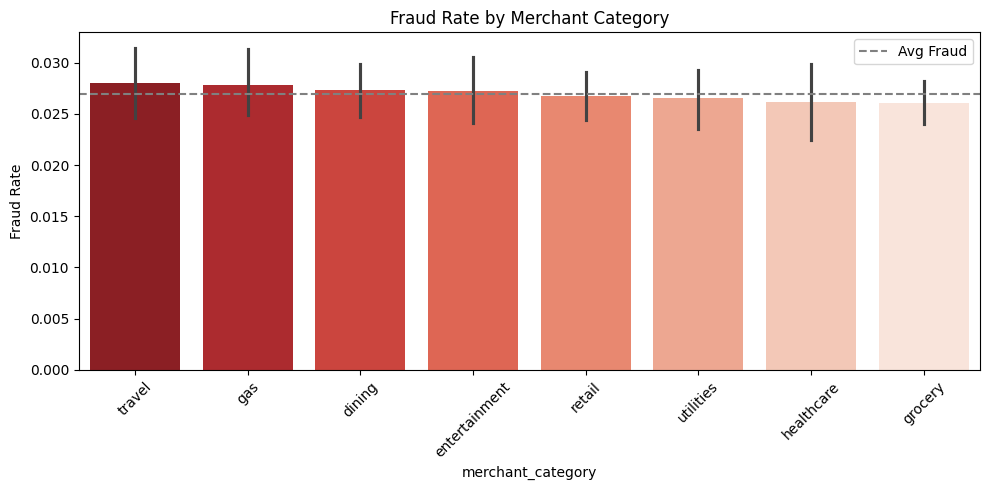

In [37]:
cat_order = df.groupby('merchant_category')['is_fraud'].mean().sort_values(ascending=False).index
plt.figure(figsize=(10, 5))
ax = sns.barplot(x='merchant_category', y='is_fraud', data=df, order=cat_order,
                 palette='Reds_r')
ax.axhline(df['is_fraud'].mean(), color='gray', linestyle='--', label='Avg Fraud')
plt.title('Fraud Rate by Merchant Category')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
X = df.drop(['is_fraud', 'timestamp'], axis=1)
y = df['is_fraud']



In [51]:
from sklearn.model_selection import train_test_split


x_train , x_test , y_train , y_test = train_test_split(X,y,test_size=0.2,stratify=y)

In [56]:
scale_pos_weight =(y_train ==0).sum() / (y_train==1).sum()

In [58]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

numerical_features = X.select_dtypes(include = 'number').columns.tolist()
categorical_features = X.select_dtypes(include = 'object').columns.tolist()

preprocessor = ColumnTransformer([
    ('num',StandardScaler(),numerical_features),
    ('cat',OneHotEncoder(),categorical_features)
])

pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('classifier',XGBClassifier(scale_pos_weight=scale_pos_weight,random_state = 42, eval_metric ='logloss' ))
])

C:\Users\youssef besheer\AppData\Local\Temp\ipykernel_67324\3205263503.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include = 'object').columns.tolist()


In [59]:
pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [60]:
from sklearn.metrics import classification_report , confusion_matrix , roc_auc_score

y_pred = pipeline.predict(x_test)
y_proba = pipeline.predict_proba(x_test)[:,1]


print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}')

              precision    recall  f1-score   support

       Legit       0.99      0.94      0.97     19462
       Fraud       0.26      0.71      0.38       538

    accuracy                           0.94     20000
   macro avg       0.63      0.83      0.67     20000
weighted avg       0.97      0.94      0.95     20000

ROC-AUC: 0.928


In [61]:
y_pred_25 = (y_proba >= 0.25).astype(int)
print(classification_report(y_test, y_pred_25, target_names=['Legit', 'Fraud']))

              precision    recall  f1-score   support

       Legit       0.99      0.90      0.95     19462
       Fraud       0.18      0.79      0.30       538

    accuracy                           0.90     20000
   macro avg       0.59      0.85      0.62     20000
weighted avg       0.97      0.90      0.93     20000



In [63]:
from sklearn.ensemble import IsolationForest
iso_features = X.select_dtypes('number').columns.tolist()
scaler = StandardScaler()
X_iso_scaled = scaler.fit_transform(X[iso_features])
iso = IsolationForest(contamination=0.03, random_state=42)
iso.fit(X_iso_scaled)
y_iso_pred = iso.predict(X_iso_scaled)
y_iso_score = iso.score_samples(X_iso_scaled)
# Convert: IsolationForest returns -1 for anomalies, 1 for normal
y_iso_binary = (y_iso_pred == -1).astype(int)
print(classification_report(y, y_iso_binary, target_names=['Legit', 'Fraud']))

              precision    recall  f1-score   support

       Legit       0.98      0.97      0.98     97312
       Fraud       0.19      0.21      0.20      2688

    accuracy                           0.95    100000
   macro avg       0.58      0.59      0.59    100000
weighted avg       0.96      0.95      0.96    100000



In [65]:
# Fit on train only
iso.fit(scaler.fit_transform(x_train[iso_features]))
# Score test set
X_test_iso = scaler.transform(x_test[iso_features])
y_iso_test_score = iso.score_samples(X_test_iso)
y_iso_test_pred = (y_iso_test_score < np.percentile(y_iso_test_score, 3)).astype(int)
print(classification_report(y_test, y_iso_test_pred, target_names=['Legit', 'Fraud']))

              precision    recall  f1-score   support

       Legit       0.98      0.98      0.98     19462
       Fraud       0.20      0.22      0.21       538

    accuracy                           0.95     20000
   macro avg       0.59      0.60      0.59     20000
weighted avg       0.96      0.95      0.96     20000



In [70]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
# Split
X = df.drop(['is_fraud', 'timestamp'], axis=1)
y = df['is_fraud']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
# Scale numerical features
num_features = X.select_dtypes('number').columns.tolist()
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[num_features])
X_test_num = scaler.transform(X_test[num_features])
# Train autoencoder on legit transactions only
X_ae_train = X_train_num[y_train.values == 0]
tensor_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_ae_train)),
    batch_size=256, shuffle=True
)
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, input_dim),
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))
model = Autoencoder(X_ae_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
model.train()
for epoch in range(20):
    for batch in tensor_loader:
        x = batch[0]
        recon = model(x)
        loss = criterion(recon, x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f'Epoch {epoch+1:2d}, Loss: {loss.item():.6f}')
# Evaluate
model.eval()
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test_num)
    X_test_recon = model(X_test_tensor)
    mse = torch.mean((X_test_tensor - X_test_recon) ** 2, dim=1).numpy()
# Find threshold at ~3% contamination
thresh = np.percentile(mse, 97)
y_ae_pred = (mse > thresh).astype(int)
print(classification_report(y_test, y_ae_pred, target_names=['Legit', 'Fraud']))

Epoch  1, Loss: 0.245022
Epoch  2, Loss: 0.122786
Epoch  3, Loss: 0.036215
Epoch  4, Loss: 0.018419
Epoch  5, Loss: 0.012894
Epoch  6, Loss: 0.054819
Epoch  7, Loss: 0.057259
Epoch  8, Loss: 0.008146
Epoch  9, Loss: 0.088981
Epoch 10, Loss: 0.011115
Epoch 11, Loss: 0.040136
Epoch 12, Loss: 0.021588
Epoch 13, Loss: 0.018517
Epoch 14, Loss: 0.028253
Epoch 15, Loss: 0.047630
Epoch 16, Loss: 0.012332
Epoch 17, Loss: 0.031048
Epoch 18, Loss: 0.020889
Epoch 19, Loss: 0.007188
Epoch 20, Loss: 0.002925
              precision    recall  f1-score   support

       Legit       0.97      0.97      0.97     19462
       Fraud       0.06      0.07      0.07       538

    accuracy                           0.95     20000
   macro avg       0.52      0.52      0.52     20000
weighted avg       0.95      0.95      0.95     20000



Epoch 10, Loss: 0.363436
Epoch 20, Loss: 0.208475
Epoch 30, Loss: 0.188214
Epoch 40, Loss: 0.143334
Epoch 50, Loss: 0.054759
Threshold sweep:
  p95: recall=0.15, precision=0.08
  p96: recall=0.13, precision=0.09
  p97: recall=0.09, precision=0.08
  p98: recall=0.06, precision=0.08
  p99: recall=0.04, precision=0.10


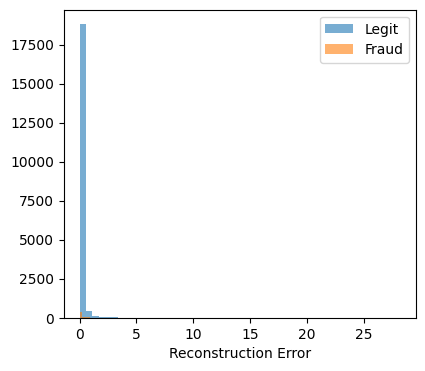

In [71]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 24), nn.ReLU(),
            nn.Linear(24, 12), nn.ReLU(),
            nn.Linear(12, 6), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(6, 12), nn.ReLU(),
            nn.Linear(12, 24), nn.ReLU(),
            nn.Linear(24, input_dim),
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

model = Autoencoder(X_ae_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
loader = DataLoader(TensorDataset(torch.FloatTensor(X_ae_train)), batch_size=256, shuffle=True)

model.train()
for epoch in range(50):
    for batch in loader:
        x = batch[0]
        recon = model(x)
        loss = criterion(recon, x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:2d}, Loss: {loss.item():.6f}')

model.eval()
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test_num)
    mse = torch.mean((X_test_tensor - model(X_test_tensor)) ** 2, dim=1).numpy()

mse_legit = mse[y_test == 0]
mse_fraud = mse[y_test == 1]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(mse_legit, bins=50, alpha=0.6, label='Legit')
plt.hist(mse_fraud, bins=50, alpha=0.6, label='Fraud')
plt.xlabel('Reconstruction Error')
plt.legend()

print('Threshold sweep:')
for pct in [95, 96, 97, 98, 99]:
    thresh = np.percentile(mse, pct)
    y_pred = (mse > thresh).astype(int)
    recall = (y_pred[y_test == 1]).sum() / (y_test == 1).sum()
    prec = (y_pred[y_test == 1]).sum() / y_pred.sum()
    print(f'  p{pct}: recall={recall:.2f}, precision={prec:.2f}')


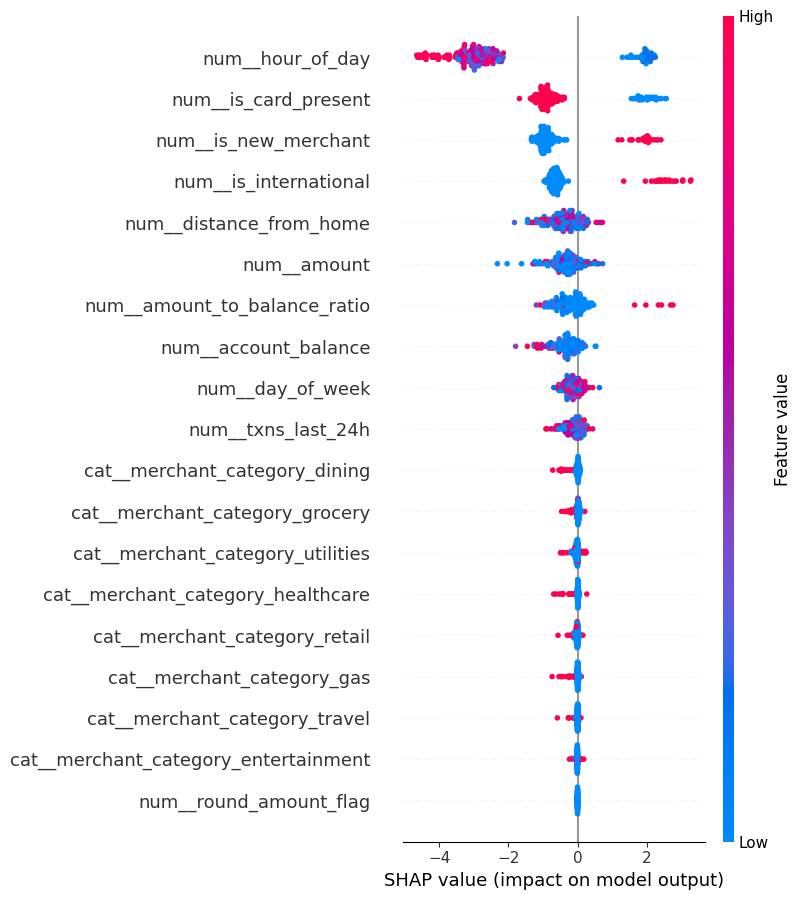

In [73]:
import shap

x_test_sample = x_test.sample(200,random_state=42)
x_test_processed = pipeline.named_steps['preprocessor'].transform(x_test_sample)

explainer = shap.TreeExplainer(pipeline.named_steps['classifier'])
shap_values = explainer.shap_values(x_test_processed)

shap.summary_plot(shap_values,x_test_processed,feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out())

In [74]:
import joblib
joblib.dump(pipeline, 'fraud_pipeline.pkl')

['fraud_pipeline.pkl']